# Analyse exploratoire (EDA) — Dataset d'interactions RAG
**Agent RAG Microfinance au Cameroun — Semaine 4**

Ce notebook analyse le dataset final de 310 interactions (S2 + S3), conformement
a la section 2.2 du cahier des charges : *"Realiser une analyse exploratoire (EDA)
caracterisant l'usage du systeme : types de requetes, frequence, taux de succes,
temps de reponse."*


In [1]:
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.max_colwidth", 80)
plt.rcParams["figure.figsize"] = (10, 5)

df = pd.read_csv("../data/processed/dataset_final_nettoye.csv", encoding="utf-8")
df["timestamp"] = pd.to_datetime(df["timestamp"], errors="coerce")
print(f"{len(df)} interactions chargees")
df.head(3)


310 interactions chargees


,id,categorie,question,reponse,nb_documents_recuperes,score_similarite,temps_reponse_secondes,statut,source,corrige_bug_decoupage_region,timestamp,succes,valide
0,Q01,definitions,Qu'est-ce que la microfinance ?,La microfinance est un système qui fournit des services financiers à des mén...,23,NaN,296.68,succes,S2,False,2026-07-30 10:27:24,True,True
1,Q02,definitions,Qu'est-ce que le microcredit ?,Le microcrédit consiste en l'attribution de prêts de faible montant à des en...,22,NaN,184.73,succes,S2,False,2026-07-30 10:30:29,True,True
2,Q03,definitions,Qu'est-ce qu'une tontine ?,Une tontine est une association collective d’épargne qui réunit des épargnan...,23,NaN,196.30,succes,S2,False,2026-07-30 10:33:45,True,True


## 1. Vue d'ensemble du dataset

In [2]:
print("Dimensions :", df.shape)
print()
print("Types de donnees :")
print(df.dtypes)
print()
print("Valeurs manquantes par colonne :")
print(df.isna().sum())


Dimensions : (310, 13)

Types de donnees :
id                                         str
categorie                                  str
question                                   str
reponse                                    str
nb_documents_recuperes                   int64
score_similarite                       float64
temps_reponse_secondes                 float64
statut                                     str
source                                     str
corrige_bug_decoupage_region              bool
timestamp                       datetime64[us]
succes                                    bool
valide                                    bool
dtype: object

Valeurs manquantes par colonne :
id                               0
categorie                        0
question                         0
reponse                          0
nb_documents_recuperes           0
score_similarite                34
temps_reponse_secondes           0
statut                           0
source            

## 2. Distribution des categories de requetes

Le cahier des charges demande explicitement d'etudier les *"types de requetes"*.
On verifie ici que la repartition entre les 9 categories reste equilibree
(rappel : un premier essai automatique avait genere 65% de questions
geo_tabulaire avant correction).

                nombre  pourcentage
categorie                          
geo_tabulaire       65         21.0
scenario            58         18.7
reglementation      47         15.2
definitions         35         11.3
hors_perimetre      25          8.1
ambigue             20          6.5
comparaison         20          6.5
chiffres            18          5.8
institutions        17          5.5
categories_emf       5          1.6


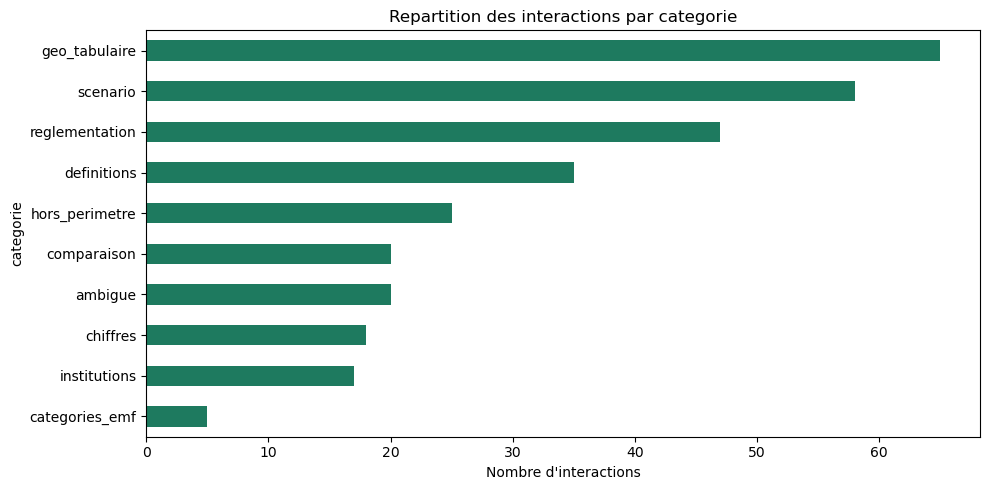

In [3]:
repartition = df["categorie"].value_counts()
pourcentages = df["categorie"].value_counts(normalize=True) * 100

resume_categories = pd.DataFrame({
    "nombre": repartition,
    "pourcentage": pourcentages.round(1),
})
print(resume_categories)

fig, ax = plt.subplots()
repartition.sort_values().plot(kind="barh", ax=ax, color="#1E7A5F")
ax.set_xlabel("Nombre d'interactions")
ax.set_title("Repartition des interactions par categorie")
plt.tight_layout()
plt.show()


## 3. Temps de reponse

Analyse de la latence de l'agent, globalement et par categorie.

In [4]:
print("Statistiques globales du temps de reponse (secondes) :")
print(df["temps_reponse_secondes"].describe().round(1))


Statistiques globales du temps de reponse (secondes) :
count     310.0
mean      141.0
std       345.7
min         9.3
25%        87.5
50%       111.1
75%       147.4
max      6142.0
Name: temps_reponse_secondes, dtype: float64


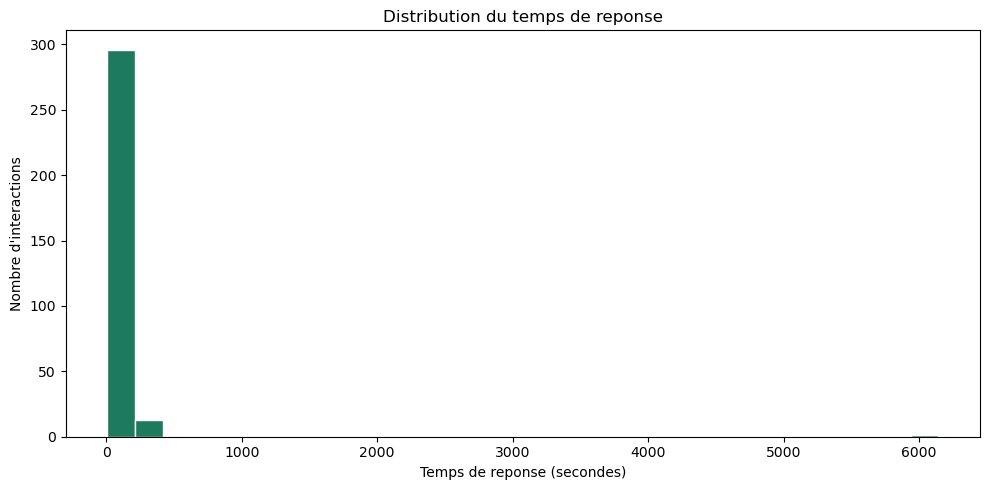

In [5]:
fig, ax = plt.subplots()
df["temps_reponse_secondes"].plot(kind="hist", bins=30, ax=ax, color="#1E7A5F", edgecolor="white")
ax.set_xlabel("Temps de reponse (secondes)")
ax.set_ylabel("Nombre d'interactions")
ax.set_title("Distribution du temps de reponse")
plt.tight_layout()
plt.show()


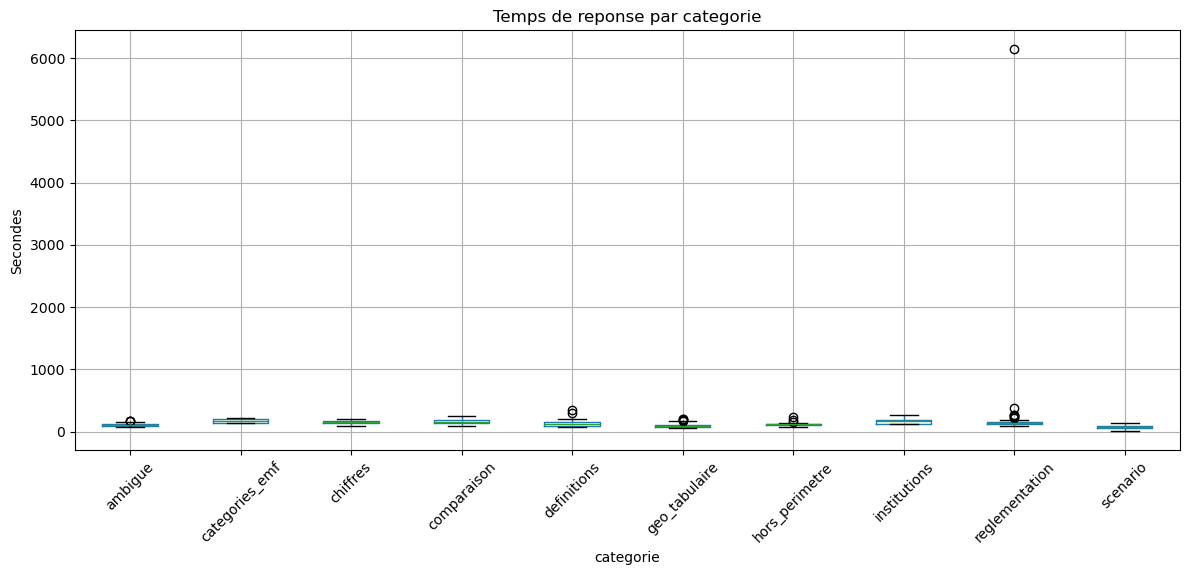

In [6]:
fig, ax = plt.subplots(figsize=(12, 6))
df.boxplot(column="temps_reponse_secondes", by="categorie", ax=ax, rot=45)
plt.suptitle("")
ax.set_title("Temps de reponse par categorie")
ax.set_ylabel("Secondes")
plt.tight_layout()
plt.show()


## 4. Taux de succes et d'abstention

Le champ `succes` (booleen) indique un succes technique (pas d'erreur). On
etudie en complement le taux d'**abstention explicite** ("je ne dispose pas
de cette information"), qui est un comportement honnete attendu, pas un
echec technique.

In [7]:
taux_succes_technique = df["succes"].mean() * 100
print(f"Taux de succes technique global : {taux_succes_technique:.1f}%")

PHRASE_ABSTENTION = "je ne dispose pas de cette information"
df["abstention"] = df["reponse"].str.lower().str.contains(PHRASE_ABSTENTION, na=False)

taux_abstention = df["abstention"].mean() * 100
print(f"Taux d'abstention explicite global : {taux_abstention:.1f}%")

print()
print("Taux d'abstention par categorie :")
print((df.groupby("categorie")["abstention"].mean() * 100).round(1).sort_values(ascending=False))


Taux de succes technique global : 100.0%
Taux d'abstention explicite global : 49.7%

Taux d'abstention par categorie :
categorie
scenario          100.0
hors_perimetre     60.0
ambigue            55.0
chiffres           44.4
geo_tabulaire      40.0
comparaison        40.0
reglementation     38.3
definitions        20.0
institutions       17.6
categories_emf      0.0
Name: abstention, dtype: float64


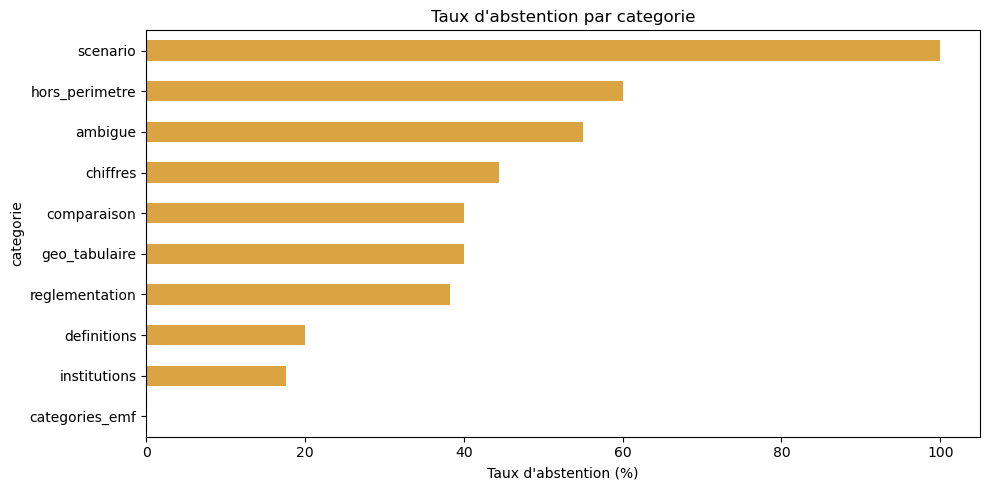

In [8]:
fig, ax = plt.subplots()
(df.groupby("categorie")["abstention"].mean() * 100).sort_values().plot(
    kind="barh", ax=ax, color="#D9A441"
)
ax.set_xlabel("Taux d'abstention (%)")
ax.set_title("Taux d'abstention par categorie")
plt.tight_layout()
plt.show()


## 5. Score de similarite semantique

Rappel important : ce score n'existe **pas** pour les interactions issues de
S2 (colonne ajoutee apres cette campagne) — elles apparaissent comme valeurs
manquantes (NaN), volontairement non comblees.

In [9]:
print(f"Valeurs manquantes (source S2) : {df['score_similarite'].isna().sum()}")
print()
print("Statistiques du score de similarite (hors valeurs manquantes) :")
print(df["score_similarite"].describe().round(3))


Valeurs manquantes (source S2) : 34

Statistiques du score de similarite (hors valeurs manquantes) :
count    276.000
mean       0.101
std        0.028
min        0.036
25%        0.084
50%        0.102
75%        0.118
max        0.193
Name: score_similarite, dtype: float64


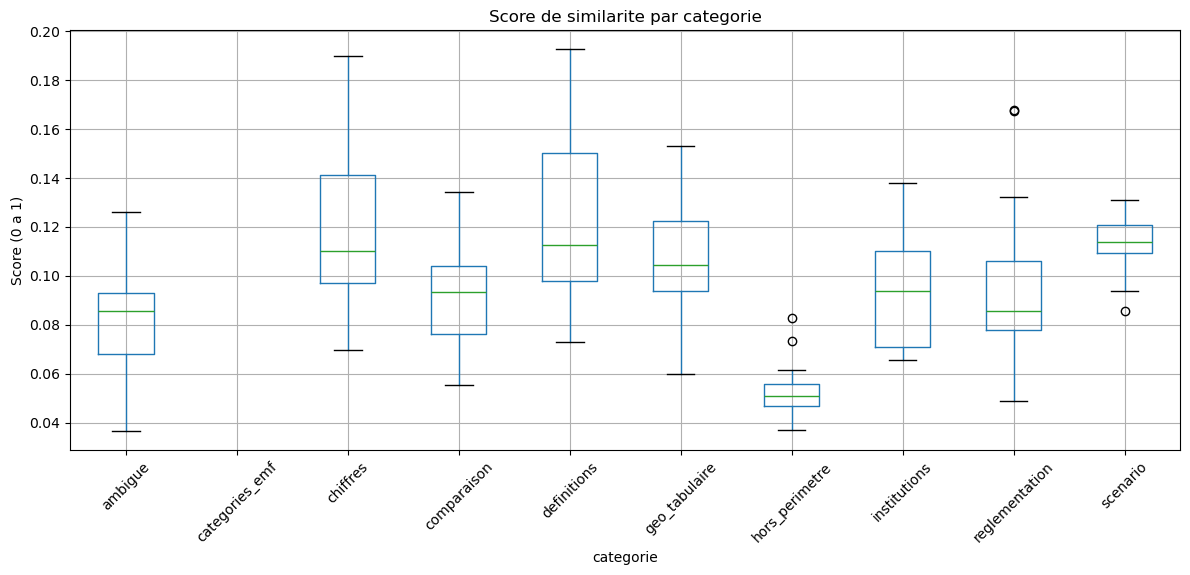

Observation attendue : les questions hors_perimetre devraient avoir
un score plus bas que les questions du domaine (signal discriminant).


In [10]:
fig, ax = plt.subplots(figsize=(12, 6))
df.boxplot(column="score_similarite", by="categorie", ax=ax, rot=45)
plt.suptitle("")
ax.set_title("Score de similarite par categorie")
ax.set_ylabel("Score (0 a 1)")
plt.tight_layout()
plt.show()

print("Observation attendue : les questions hors_perimetre devraient avoir")
print("un score plus bas que les questions du domaine (signal discriminant).")


## 6. Tableau de synthese croise (categorie x indicateurs)

Ce tableau croise les categories avec les indicateurs cles, comme demande
implicitement par le cahier des charges pour preparer l'interpretation
croisee avec RAGAS en section 5.7.

In [11]:
synthese = df.groupby("categorie").agg(
    nb_interactions=("id", "count"),
    temps_moyen_s=("temps_reponse_secondes", "mean"),
    taux_abstention_pct=("abstention", lambda x: x.mean() * 100),
    score_similarite_moyen=("score_similarite", "mean"),
    taux_succes_technique_pct=("succes", lambda x: x.mean() * 100),
).round(2).sort_values("nb_interactions", ascending=False)

synthese


,nb_interactions,temps_moyen_s,taux_abstention_pct,score_similarite_moyen,taux_succes_technique_pct
categorie,,,,,
geo_tabulaire,65,103.26,40.00,0.11,100.0
scenario,58,72.83,100.00,0.11,100.0
reglementation,47,277.50,38.30,0.09,100.0
definitions,35,135.63,20.00,0.12,100.0
hors_perimetre,25,119.45,60.00,0.05,100.0
ambigue,20,113.46,55.00,0.08,100.0
comparaison,20,161.21,40.00,0.09,100.0
chiffres,18,154.51,44.44,0.12,100.0
institutions,17,167.30,17.65,0.09,100.0


In [12]:
synthese.to_csv("../data/processed/synthese_eda_par_categorie.csv", encoding="utf-8-sig")
print("Tableau de synthese sauvegarde dans data/processed/synthese_eda_par_categorie.csv")


Tableau de synthese sauvegarde dans data/processed/synthese_eda_par_categorie.csv


## 7. Provenance des donnees et corrections tracees

Verification de la repartition S2/S3 et du nombre de lignes corrigees suite
au bug de decoupage region/footer (tracabilite, cf. Semaine 3).

In [ ]:
print("Repartition par source :")
print(df["source"].value_counts())
print()
print(f"Lignes corrigees (bugfix decoupage region) : {df['corrige_bug_decoupage_region'].sum()}")
print(f"Lignes valides (regles metier) : {df['valide'].sum()} / {len(df)}")




Repartition par source :
source
S3    275
S2     35
Name: count, dtype: int64

Lignes corrigees (bugfix decoupage region) : 8
Lignes valides (regles metier) : 310 / 310


In [14]:
with open("../data/processed/diagnostic_scenario_et_temps.txt", "w", encoding="utf-8") as f:
    f.write("=== 5 TEMPS DE REPONSE LES PLUS LONGS ===\n\n")
    f.write(df.nlargest(5, "temps_reponse_secondes")[
        ["id", "categorie", "question", "temps_reponse_secondes"]
    ].to_string())

    f.write("\n\n=== 3 EXEMPLES DE REPONSES 'SCENARIO' ===\n\n")
    for _, ligne in df[df["categorie"] == "scenario"].sample(3, random_state=1).iterrows():
        f.write(f"--- {ligne['id']} ---\n")
        f.write(ligne["question"] + "\n")
        f.write(ligne["reponse"][:500] + "\n\n")

print("Fichier exporte : data/processed/diagnostic_scenario_et_temps.txt")

Fichier exporte : data/processed/diagnostic_scenario_et_temps.txt


## Conclusions de l'EDA (a completer apres execution)

- Repartition des categories : *(a commenter selon les chiffres obtenus)*
- Temps de reponse : *(a commenter — variance entre categories ?)*
- Taux d'abstention : *(les categories hors_perimetre s'abstiennent-elles plus ?)*
- Score de similarite : *(confirme-t-il un signal discriminant utile pour S5 ?)*

**Prochaine etape** : calcul des 4 metriques RAGAS (Faithfulness, Answer
Relevancy, Context Precision, Context Recall) et croisement avec ces
memes categories, conformement a la section 5.7 du cahier des charges.
